In [ ]:
!pip install transformers accelerate -q


In [ ]:
import transformers
print(transformers.__version__)

5.0.0


In [ ]:

import pandas as pd
import numpy as np
import re
import torch
from google.colab import files
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [ ]:
print("Uploadexcel file : ")
uploaded = files.upload()

file_name = None
for fn in uploaded.keys():
    # قبول CSV
    if fn.endswith(".csv"):
        file_name = fn
        file_type = "csv"
        break
    # قبول Excel
    elif fn.endswith(".xlsx") or fn.endswith(".xls"):
        file_name = fn
        file_type = "excel"
        break

if file_name is None:
    raise ValueError("Please upload a CSV or Excel file.")

print(f" Uploaded file: {file_name}")

# قراءة الملف حسب النوع
if file_type == "csv":
    df = pd.read_csv(file_name)
else:
    df = pd.read_excel(file_name)

df.columns = df.columns.str.strip()

print("\n Columns found:")
print(df.columns)

print(" القيم الموجودة في عمود 'المتحدث':")
print(df["المتحدث"].unique())


Uploadexcel file : 


Saving sharing dataset file .xlsx to sharing dataset file .xlsx
 Uploaded file: sharing dataset file .xlsx

 Columns found:
Index(['الطابع الزمني', 'الدور', 'المتحدث', 'الجملة', 'علامة المعلم',
       'علامة الطالب'],
      dtype='object')
 القيم الموجودة في عمود 'المتحدث':
['م' 'سيسيليو ديماس' 'ت/ر١' 'إريك' 'مايكل' 'دانييل' 'آلان' 'جيف' 'م٢ '
 'كيفن' 'ط' 'أندرو' 'ميريديث' 'ديفيد' 'طالب/طالبة' 'برايان' 'جيسيكا'
 'ط ط ' 'صموئيل' 'س ن' 'بيث' 'ميشيل' 'أليسا' 'شريك' 'جاكي' 'سينثيا' 'أوسي'
 'ميلين' 'ساوراب' 'ليندا فيشر' 'لورا' 'دانيال' 'كلير' 'أشانك' 'جاكلين'
 'شارلوت' 'م ٢ ' 'ستيفاني' 'طالب/طالبة 1' 'آمي' 'ستيفاني وجيف'
 'الآنسة ليو' 'غريغوري' 'ديبورا' 'غراهام' 'أودرا' 'جايك' 'طلاب' 'تيموثي'
 'ميريديث وديفيد' 'سي' 'جيسون' 'مارك' 'ميشيل وميلين' 'كيلي'
 'جيسيكا وأودرا' 'آخرون' nan 'شقراء' 'ميلين،' '~23' 'الجميع' 'ميشيل وجيف'
 'ر٢' 'إريك وبريان']


In [ ]:
# ============================================
# 3) فلترة الطلاب — الإصدار الصحيح والمعتمد أكاديمياً
# ============================================

import re

sentence_col = "الجملة"
student_tag_col = "علامة الطالب"

#  نعتبر كل سطر فيه علامة طالب = سطر لطالب
df_student = df[df[student_tag_col].notna()].copy()

print("\n عدد جمل الطلاب:", df_student.shape[0])
print(" أمثلة للعلامات:", df_student[student_tag_col].unique()[:20])

#  إزالة الصفوف التي لا تحتوي على نص أو علامة
df_student = df_student.dropna(subset=[sentence_col, student_tag_col])


# ============================================
# 4) تنظيف العلامات
# ============================================
def clean_tag(text):
    if pd.isna(text):
        return "لا يوجد"

    text = str(text).strip()
    text = re.sub(r"^\s*\d+\s*[-–]?\s*", "", text)
    text = re.sub(r"^[-–]\s*", "", text)
    text = text.replace(" / ", "/").replace(" /", "/").replace("/ ", "/")
    text = re.sub(r"\s+", " ", text)
    return text.strip()


# ============================================
# 5) تنظيف الجمل العربية
# ============================================
def clean_arabic_text(text):
    if pd.isna(text):
        return ""

    text = str(text)

    # إزالة التشكيل
    text = re.sub(r'[\u064B-\u0652]', '', text)

    # إزالة التطويل
    text = re.sub(r'ـ+', '', text)

    # توحيد الحروف
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)
    text = re.sub(r'ة', 'ه', text)

    # إزالة الرموز
    text = re.sub(r'[^\w\s]', ' ', text)

    # إزالة تكرار الحرف
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # إزالة المسافات المتكررة
    text = re.sub(r'\s+', ' ', text).strip()

    return text


# تطبيق تنظيف العلامات
df_student[student_tag_col] = df_student[student_tag_col].apply(clean_tag)

# تطبيق تنظيف الجمل العربية (مهم جداً قبل التدريب!)
df_student[sentence_col] = df_student[sentence_col].apply(clean_arabic_text)

print("\n قيم علامة الطالب بعد التنظيف:")
print(df_student[student_tag_col].value_counts())

# ============================================
# 5.1) فلترة الجمل غير العربية بعد التنظيف
# ============================================
def is_mostly_arabic(text, threshold=0.5):
    if pd.isna(text):
        return False
    text = str(text)
    arabic_chars = re.findall(r'[\u0600-\u06FF]', text)
    return (len(arabic_chars) / len(text)) >= threshold if len(text) > 0 else False

before = df_student.shape[0]
df_student = df_student[df_student[sentence_col].apply(is_mostly_arabic)].copy()
after = df_student.shape[0]

print(f"\nعدد الجمل بعد فلترة غير العربي: {after}")
print(f"عدد الجمل المحذوفة: {before - after}")


 عدد جمل الطلاب: 1498
 أمثلة للعلامات: ['1 - لا يوجد' '4 - تقديم مطالبة' '5 - تقديم أدلة / شرح الأسباب'
 '2 - التواصل مع طالب آخر' '3 - طلب المزيد من المعلومات' '3 - طلب معلومات']

 قيم علامة الطالب بعد التنظيف:
علامة الطالب
لا يوجد                    443
تقديم أدلة/شرح الأسباب     421
تقديم مطالبة               336
التواصل مع طالب آخر        257
طلب المزيد من المعلومات     38
طلب معلومات                  3
Name: count, dtype: int64

عدد الجمل بعد فلترة غير العربي: 1463
عدد الجمل المحذوفة: 35


In [ ]:
# 5) تحويل العلامات إلى مستويات (0–3) — النسخة النهائية

import os
os.environ["WANDB_DISABLED"] = "true"
def map_to_level(tag):
    if pd.isna(tag):
        return 0

    t = clean_tag(tag)

    # Level 0
    if t == "لا يوجد":
        return 0

    # Level 1
    if t in ["تقديم مطالبة", "طلب معلومات"]:
        return 1

    # Level 2
    if t in ["تقديم أدلة/شرح الأسباب", "طلب المزيد من المعلومات"]:
        return 2

    # Level 3
    if t == "التواصل مع طالب آخر":
        return 3

    return 0


df_student["thinking_level"] = df_student[student_tag_col].apply(map_to_level)

# الشرح
explain_levels = {
    0: "لا يوجد تفكير استدلالي واضح",
    1: "ادعاء فقط بدون أدلة",
    2: "تفكير متوسط: تقديم دليل أو شرح أسباب",
    3: "تفكير أعلى: الربط أو طلب معلومات"
}

df_student["التفسير"] = df_student["thinking_level"].apply(lambda x: explain_levels[x])

print("\n توزيع مستويات التفكير:")
print(df_student["thinking_level"].value_counts().sort_index())




 توزيع مستويات التفكير:
thinking_level
0    437
1    323
2    448
3    255
Name: count, dtype: int64


In [ ]:
# 6) تجهيز بيانات التدريب
texts = df_student[sentence_col].astype(str).tolist()
labels = df_student["thinking_level"].astype(int).tolist()

X_train, X_test, y_train, y_test = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print(f"\n تدريب: {len(X_train)}")
print(f" اختبار: {len(X_test)}")

print("\n توزيع فئات test set:")
print(pd.Series(y_test).value_counts().sort_index())




 تدريب: 1170
 اختبار: 293

 توزيع فئات test set:
0    87
1    65
2    90
3    51
Name: count, dtype: int64


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside


بدء تدريب AraBERT على جمل الطلاب...


Epoch,Training Loss,Validation Loss,Accuracy
1,1.099460,1.009588,0.610922
2,1.145965,0.888276,0.621160
3,0.863261,0.893842,0.651877
4,0.555136,1.024077,0.655290
5,0.341834,1.098081,0.662116
6,0.545974,1.361139,0.655290
7,0.466675,1.502742,0.692833
8,0.192697,1.690516,0.675768
9,0.310028,1.724571,0.686007
10,0.241688,1.736203,0.679181


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


 Accuracy: 0.6177474402730375

 Classification Report:
              precision    recall  f1-score   support

           0      0.831     0.678     0.747        87
           1      0.431     0.677     0.527        65
           2      0.733     0.700     0.716        90
           3      0.441     0.294     0.353        51

    accuracy                          0.618       293
   macro avg      0.609     0.587     0.586       293
weighted avg      0.644     0.618     0.620       293



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

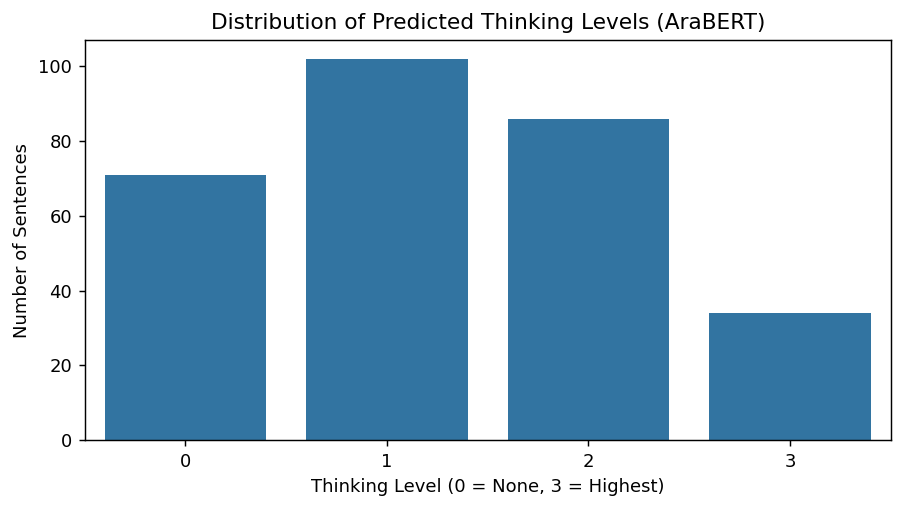

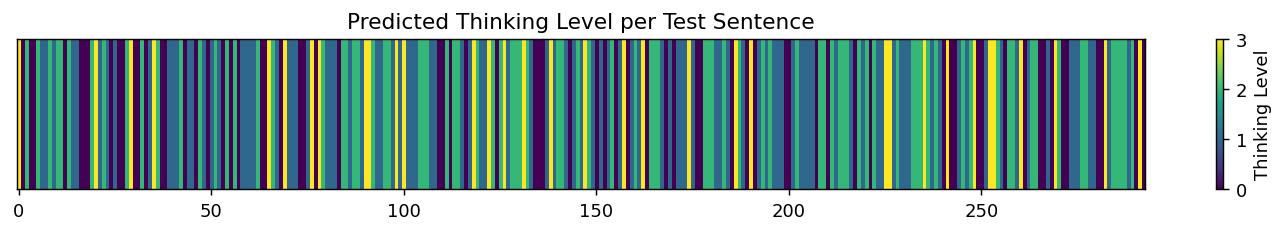

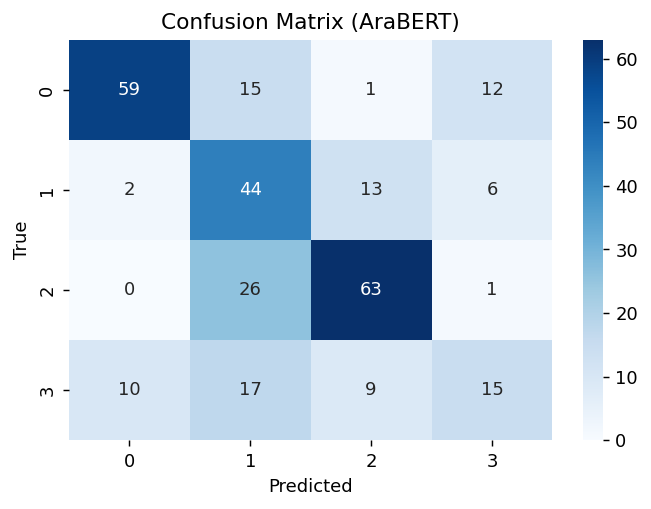

<Figure size 1040x520 with 0 Axes>

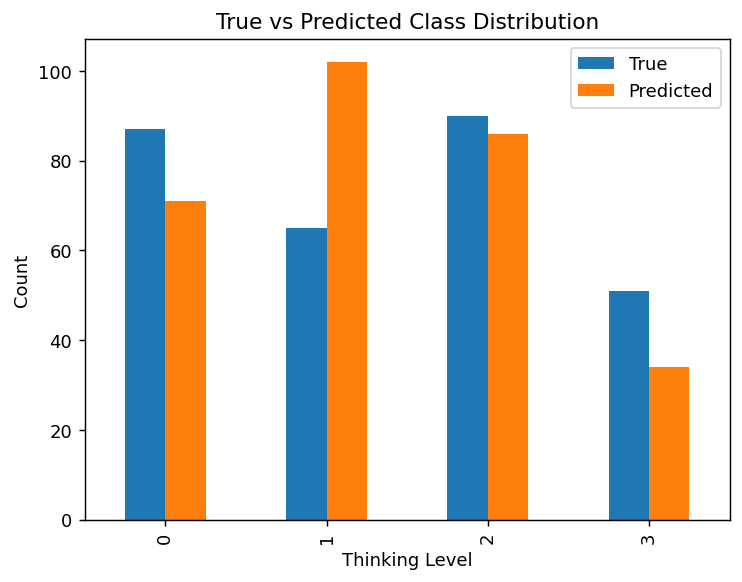

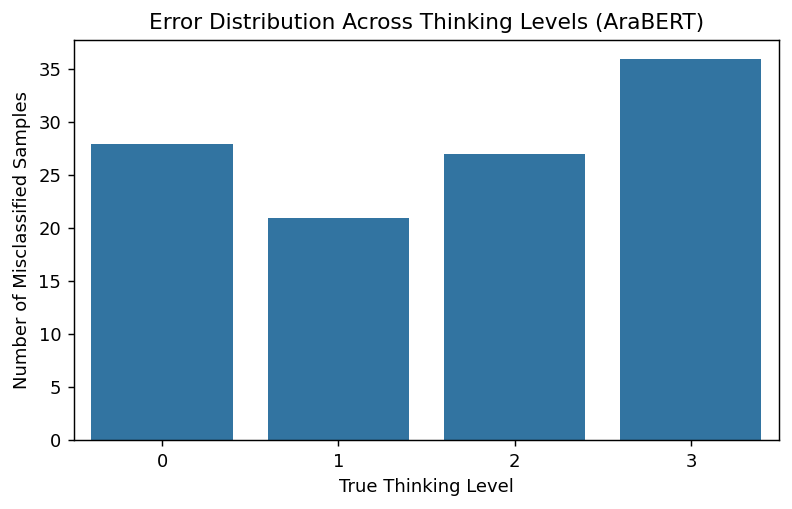


🔍 أول 20 مثال من الجمل التي أخطأ فيها النموذج:


,Sentence,True Level,Predicted Level
0,لا احد سيفهم خاصتي,0,3
1,علي سبيل المثال في عمود واحد يحتوي علي في صف و...,1,2
2,لقد استخدمنا قضبان كويزينير الخاصه بنا,0,1
3,سيكون هناك 3 اعلي منها لذلك سيكون هناك,1,2
4,لا هذا هو الاخر,3,1
5,لا لا يفعل,3,0
6,حسنا,3,0
7,لذا فهو يعتقد ان كل منهما 9 اكواب فهو نسي كل ا...,3,2
8,لكن هذا هذا لثلاثه,2,1
9,لا تغييرات,1,3


In [ ]:
# 7) تحميل AraBERT
model_name = "aubmindlab/bert-base-arabertv02"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, num_labels=4
).to(device)

# 8) Dataset
class ArabicReasoningDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding=False,
            max_length=self.max_length,
        )
        item = {k: torch.tensor(v) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


train_dataset = ArabicReasoningDataset(X_train, y_train, tokenizer)
test_dataset  = ArabicReasoningDataset(X_test,  y_test,  tokenizer)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


# 9) Trainer
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}


training_args = TrainingArguments(
    output_dir="./arabert_reasoning",
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    greater_is_better=True,
    seed=42
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)



# 10) التدريب
print("\nبدء تدريب AraBERT على جمل الطلاب...")
trainer.train()



# 11) التقييم
eval_output = trainer.evaluate()
print("\n Accuracy:", eval_output["eval_accuracy"])

preds_logits = trainer.predict(test_dataset).predictions
preds = np.argmax(preds_logits, axis=-1)

print("\n Classification Report:")
print(classification_report(y_test, preds, digits=3))



# 12) التوقع لكل جملة طالب (Batching)

df_student[sentence_col] = df_student[sentence_col].astype(str)

def predict_levels(text_list, batch_size=16):
    all_preds = []
    model.eval()
    for i in range(0, len(text_list), batch_size):
        batch = text_list[i:i+batch_size]
        enc = tokenizer(
            batch, truncation=True, padding=True, max_length=128,
            return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            logits = model(**enc).logits
        all_preds.extend(np.argmax(logits.cpu(), axis=-1).tolist())
    return all_preds


test_predictions = predict_levels(X_test)

test_results_df = pd.DataFrame({
    "Sentence": X_test,
    "True Level": y_test,
    "Predicted Level": test_predictions
})

test_results_df["True Explanation"] = test_results_df["True Level"].apply(lambda x: explain_levels[x])
test_results_df["Predicted Explanation"] = test_results_df["Predicted Level"].apply(lambda x: explain_levels[x])


# 13) حفظ النتائج
out_name = "students_reasoning_arabert_testset.xlsx"
test_results_df.to_excel(out_name, index=False)
files.download(out_name)


# 14) الرسومات
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 130

# Histogram / Bar Plot
plt.figure(figsize=(8,4))
sns.countplot(x=test_results_df["Predicted Level"])
plt.title("Distribution of Predicted Thinking Levels (AraBERT)")
plt.xlabel("Thinking Level (0 = None, 3 = Highest)")
plt.ylabel("Number of Sentences")
plt.show()

# Heatmap Strip
plt.figure(figsize=(14, 1.5))
plt.imshow(test_results_df["Predicted Level"].values[np.newaxis, :],
           aspect="auto", cmap="viridis")
plt.yticks([])
plt.colorbar(label="Thinking Level")
plt.title("Predicted Thinking Level per Test Sentence")
plt.show()

#confusion_matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, test_predictions)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["0","1","2","3"],
            yticklabels=["0","1","2","3"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (AraBERT)")
plt.show()

# Distribution
plt.figure(figsize=(8,4))

true_counts = pd.Series(y_test).value_counts().sort_index()
pred_counts = pd.Series(test_predictions).value_counts().sort_index()

df_compare = pd.DataFrame({
    "True": true_counts,
    "Predicted": pred_counts
})

df_compare.plot(kind="bar")
plt.title("True vs Predicted Class Distribution")
plt.xlabel("Thinking Level")
plt.ylabel("Count")
plt.show()

# ============================================
# Error Distribution Plot
# ============================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

errors = (np.array(test_predictions) != np.array(y_test))
error_levels = np.array(y_test)[errors]

error_counts = pd.Series(error_levels).value_counts().reindex([0,1,2,3], fill_value=0)

plt.figure(figsize=(7,4))
sns.barplot(x=error_counts.index, y=error_counts.values)
plt.title("Error Distribution Across Thinking Levels (AraBERT)")
plt.xlabel("True Thinking Level")
plt.ylabel("Number of Misclassified Samples")
plt.show()

# ============================================
# Misclassified Examples Table
# ============================================

misclassified = []

for text, true, pred in zip(X_test, y_test, test_predictions):
    if true != pred:
        misclassified.append([text, true, pred])

mis_df = pd.DataFrame(misclassified, columns=["Sentence", "True Level", "Predicted Level"])

print("\n🔍 أول 20 مثال من الجمل التي أخطأ فيها النموذج:")
mis_df.head(20)


## **AraELECTRA**

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

model_electra_name = "aubmindlab/araelectra-base-discriminator"

tokenizer_electra = AutoTokenizer.from_pretrained(model_electra_name)

model_electra = AutoModelForSequenceClassification.from_pretrained(
    model_electra_name,
    num_labels=4
).to(device)

# مهم: إعادة بناء الـ datasets باستخدام tokenizer الخاص بـ AraELECTRA
train_dataset_electra = ArabicReasoningDataset(X_train, y_train, tokenizer_electra)
test_dataset_electra  = ArabicReasoningDataset(X_test,  y_test,  tokenizer_electra)
data_collator_electra = DataCollatorWithPadding(tokenizer=tokenizer_electra)

training_args_electra = TrainingArguments(
    output_dir="./results_araelectra",
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=20,
    seed=42,
    report_to="none",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    greater_is_better=True
)

trainer_electra = Trainer(
    model=model_electra,
    args=training_args_electra,
    train_dataset=train_dataset_electra,
    eval_dataset=test_dataset_electra,
    data_collator=data_collator_electra,
    compute_metrics=compute_metrics,
)

print("\n Starting AraELECTRA training...")
trainer_electra.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: aubmindlab/araelectra-base-discriminator
Key                                               | Status     | 
--------------------------------------------------+------------+-
electra.embeddings.position_ids                   | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.weight                        | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missin


 Starting AraELECTRA training...


Epoch,Training Loss,Validation Loss,Accuracy
1,1.077963,0.947155,0.617747
2,1.033197,0.882526,0.665529
3,0.724421,0.899528,0.689420
4,0.456178,1.067111,0.675768
5,0.321253,1.228139,0.699659
6,0.410221,1.412516,0.692833
7,0.230252,1.592759,0.692833
8,0.135209,1.634965,0.689420
9,0.398343,1.703772,0.696246
10,0.084458,1.735059,0.686007


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

TrainOutput(global_step=2930, training_loss=0.494956907843567, metrics={'train_runtime': 980.6699, 'train_samples_per_second': 11.931, 'train_steps_per_second': 2.988, 'total_flos': 123478385566224.0, 'train_loss': 0.494956907843567, 'epoch': 10.0})


 AraELECTRA Accuracy: 0.6860068259385665

 AraELECTRA Classification Report:
              precision    recall  f1-score   support

           0      0.807     0.816     0.811        87
           1      0.585     0.585     0.585        65
           2      0.747     0.789     0.768        90
           3      0.467     0.412     0.438        51

    accuracy                          0.686       293
   macro avg      0.651     0.650     0.650       293
weighted avg      0.680     0.686     0.683       293


أول 20 مثال من الجمل التي أخطأ فيها نموذج AraELECTRA:
                                                                                                                                Sentence  True Level  Predicted Level                     True Explanation                Predicted Explanation
                                                                                                                      لا احد سيفهم خاصتي           0                3          لا يوجد تفكير است

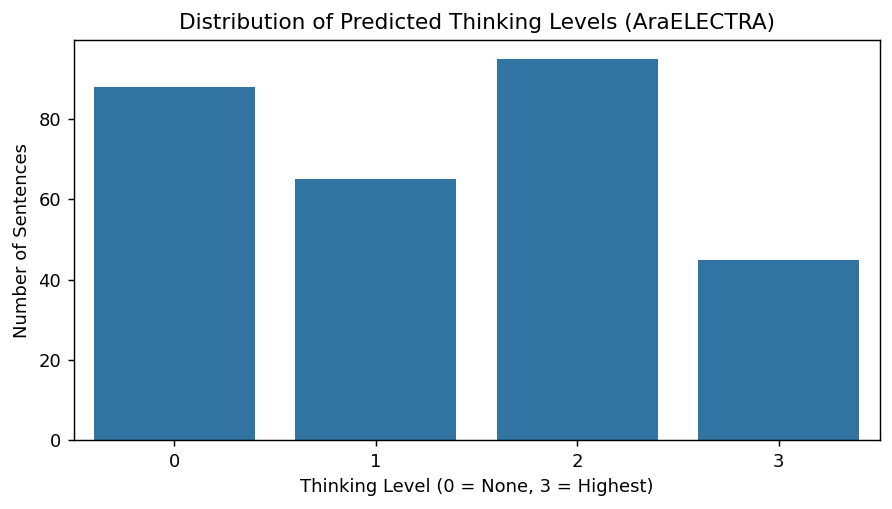

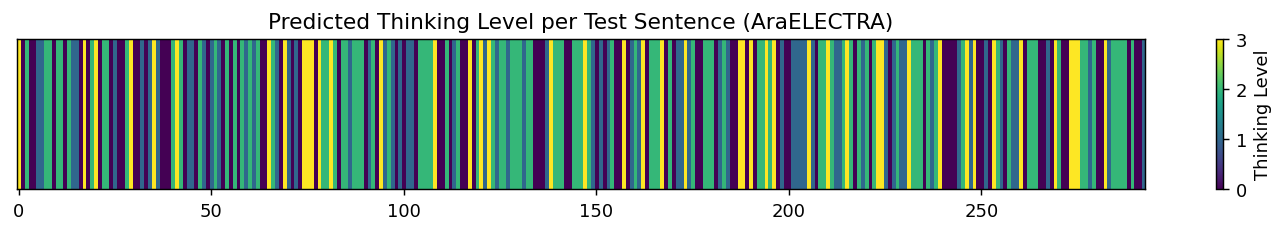

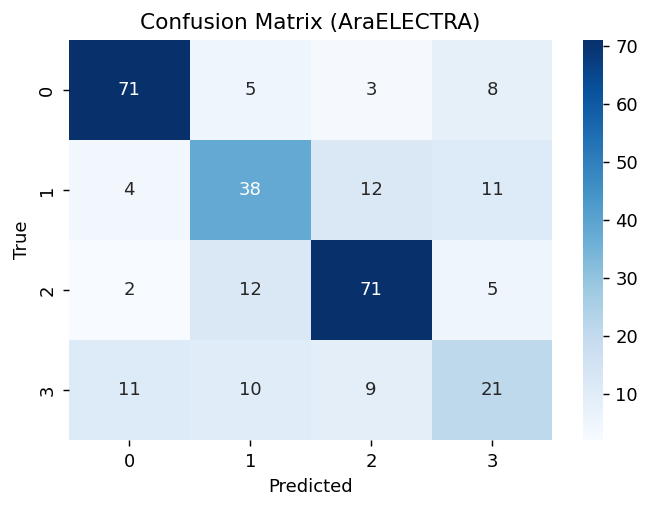

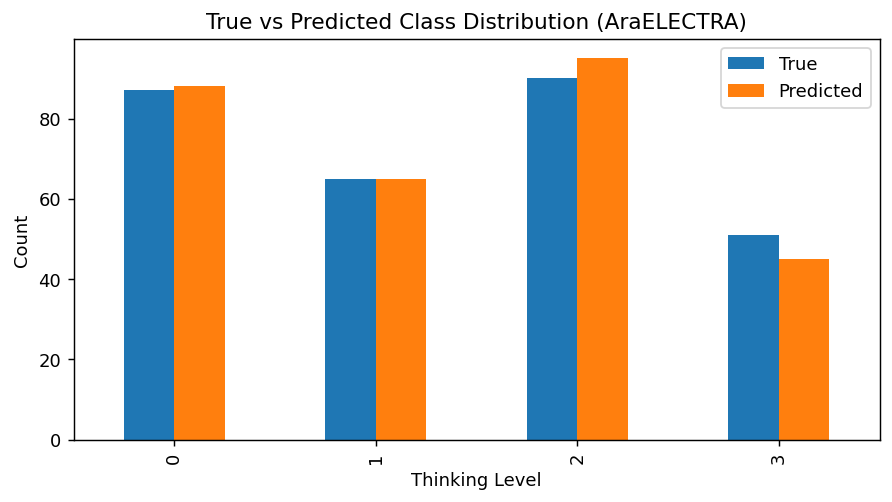

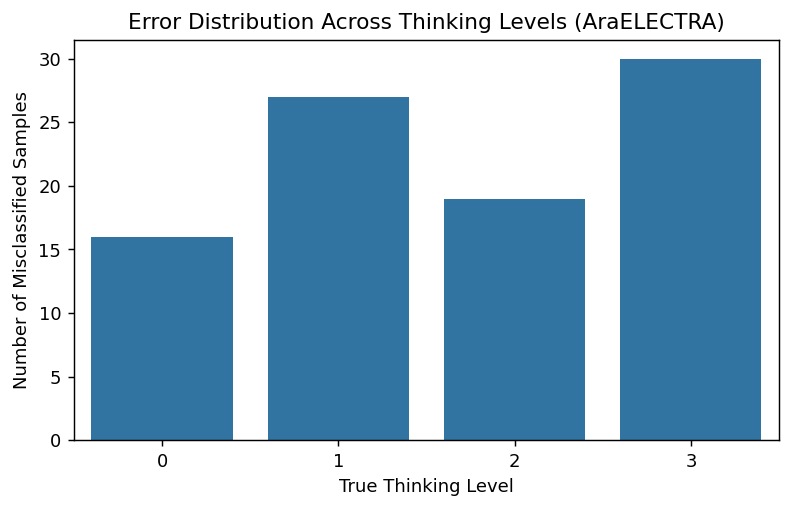

In [ ]:
eval_output_electra = trainer_electra.evaluate()
print("\n AraELECTRA Accuracy:", eval_output_electra["eval_accuracy"])

from sklearn.metrics import classification_report
import numpy as np

preds_logits_electra = trainer_electra.predict(test_dataset_electra).predictions
preds_electra = np.argmax(preds_logits_electra, axis=-1)

print("\n AraELECTRA Classification Report:")
print(classification_report(y_test, preds_electra, digits=3))

# ============================================
# Misclassified Examples Table (AraELECTRA)
# ============================================
misclassified_electra = []

for text, true, pred in zip(X_test, y_test, preds_electra):
    if int(true) != int(pred):
        misclassified_electra.append([text, int(true), int(pred)])

mis_df_electra = pd.DataFrame(
    misclassified_electra,
    columns=["Sentence", "True Level", "Predicted Level"]
)

mis_df_electra["True Explanation"] = mis_df_electra["True Level"].map(explain_levels)
mis_df_electra["Predicted Explanation"] = mis_df_electra["Predicted Level"].map(explain_levels)

print("\nأول 20 مثال من الجمل التي أخطأ فيها نموذج AraELECTRA:")
print(mis_df_electra.head(20).to_string(index=False))

# ============================================
# Distribution of Predicted Levels
# ============================================
plt.figure(figsize=(8,4))
sns.countplot(x=preds_electra)
plt.title("Distribution of Predicted Thinking Levels (AraELECTRA)")
plt.xlabel("Thinking Level (0 = None, 3 = Highest)")
plt.ylabel("Number of Sentences")
plt.show()

# ============================================
# Predicted Level per Test Sentence
# ============================================
plt.figure(figsize=(14, 1.5))
plt.imshow(np.array(preds_electra)[np.newaxis, :], aspect="auto", cmap="viridis")
plt.yticks([])
plt.colorbar(label="Thinking Level")
plt.title("Predicted Thinking Level per Test Sentence (AraELECTRA)")
plt.show()

# ============================================
# Confusion Matrix (AraELECTRA)
# ============================================
cm_electra = confusion_matrix(y_test, preds_electra)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm_electra,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=["0","1","2","3"],
    yticklabels=["0","1","2","3"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (AraELECTRA)")
plt.show()

# ============================================
# True vs Predicted Class Distribution
# ============================================
levels = [0, 1, 2, 3]

true_counts_electra = pd.Series(y_test).value_counts().reindex(levels, fill_value=0)
pred_counts_electra = pd.Series(preds_electra).value_counts().reindex(levels, fill_value=0)

df_compare_electra = pd.DataFrame({
    "True": true_counts_electra,
    "Predicted": pred_counts_electra
})

df_compare_electra.plot(kind="bar", figsize=(8,4))
plt.title("True vs Predicted Class Distribution (AraELECTRA)")
plt.xlabel("Thinking Level")
plt.ylabel("Count")
plt.show()

# ============================================
# Error Distribution Plot
# ============================================
errors_electra = (np.array(preds_electra) != np.array(y_test))
error_levels_electra = np.array(y_test)[errors_electra]

error_counts_electra = pd.Series(error_levels_electra).value_counts().reindex([0,1,2,3], fill_value=0)

plt.figure(figsize=(7,4))
sns.barplot(x=error_counts_electra.index, y=error_counts_electra.values)
plt.title("Error Distribution Across Thinking Levels (AraELECTRA)")
plt.xlabel("True Thinking Level")
plt.ylabel("Number of Misclassified Samples")
plt.show()

In [ ]:
mis_df_electra_simple = mis_df_electra[[
    "Sentence",
    "True Level",
    "Predicted Level"
]].head(11)
mis_df_electra_simple

,Sentence,True Level,Predicted Level
0,لا احد سيفهم خاصتي,0,3
1,علي سبيل المثال في عمود واحد يحتوي علي في صف و...,1,2
2,لقد استخدمنا قضبان كويزينير الخاصه بنا,0,1
3,هناك واحده حمراء وهناك واحده زرقاء,1,2
4,سيكون هناك 3 اعلي منها لذلك سيكون هناك,1,2
5,لا هذا هو الاخر,3,1
6,لا لا يفعل,3,0
7,حسنا,3,0
8,لذا فهو يعتقد ان كل منهما 9 اكواب فهو نسي كل ا...,3,2
9,ثلاث كاملات يهز الان راسه لايريك,1,0
